In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/flood_x_cleaned_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 22)


,timestamp,location,latitude,longitude,rainfall_1h_mm,rainfall_3h_mm,rainfall_6h_mm,rainfall_24h_mm,soil_moisture_percent,river_level_m,...,slope_degrees,distance_from_river_km,population,households,hospitals,schools,shelters,flood,severity,risk_score
0,2026-06-01 00:00:00,Agasthyamalai,8.649110,77.359170,0.00,15.84,29.94,50.64,54.75,1.51,...,43.04,1.10,2588.0,619.0,1.0,2.0,3.0,0,LOW,31.56
1,2026-06-01 00:00:00,Anamalai Foothills,10.551006,76.919621,3.04,20.90,35.56,63.62,50.49,1.37,...,26.99,0.48,6997.0,1661.0,3.0,6.0,5.0,0,LOW,27.60
2,2026-06-01 00:00:00,Biligiriranga Hills,11.946526,77.151641,5.90,5.05,18.62,41.53,44.63,1.20,...,33.30,1.19,3445.0,842.0,1.0,2.0,3.0,0,SAFE,17.97
3,2026-06-01 00:00:00,Javadi Hills,12.498833,78.949020,11.91,24.10,33.35,51.77,49.47,1.47,...,21.78,1.77,4655.0,1118.0,1.0,3.0,2.0,0,LOW,23.13
4,2026-06-01 00:00:00,Kalrayan Hills,11.717462,78.851742,0.00,12.39,25.05,52.58,47.99,1.50,...,23.09,1.49,5238.0,1217.0,1.0,3.0,3.0,0,LOW,24.32


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   location                  10000 non-null  object 
 2   latitude                  10000 non-null  float64
 3   longitude                 10000 non-null  float64
 4   rainfall_1h_mm            10000 non-null  float64
 5   rainfall_3h_mm            10000 non-null  float64
 6   rainfall_6h_mm            10000 non-null  float64
 7   rainfall_24h_mm           10000 non-null  float64
 8   soil_moisture_percent     10000 non-null  float64
 9   river_level_m             10000 non-null  float64
 10  river_rise_rate_m_per_hr  10000 non-null  float64
 11  elevation_m               10000 non-null  float64
 12  slope_degrees             10000 non-null  float64
 13  distance_from_river_km    10000 non-null  float64
 14  populat

In [4]:
df.isnull().sum()

timestamp                   0
location                    0
latitude                    0
longitude                   0
rainfall_1h_mm              0
rainfall_3h_mm              0
rainfall_6h_mm              0
rainfall_24h_mm             0
soil_moisture_percent       0
river_level_m               0
river_rise_rate_m_per_hr    0
elevation_m                 0
slope_degrees               0
distance_from_river_km      0
population                  0
households                  0
hospitals                   0
schools                     0
shelters                    0
flood                       0
severity                    0
risk_score                  0
dtype: int64

flood
0    7310
1    2690
Name: count, dtype: int64


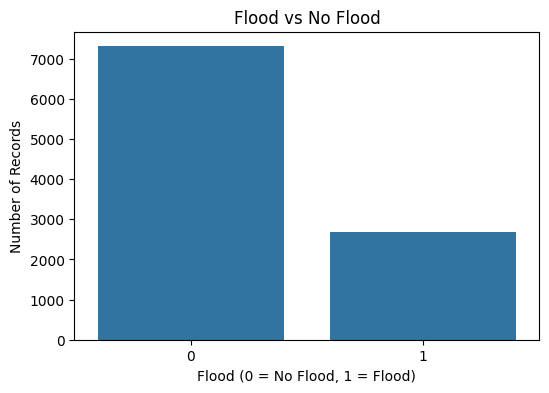

In [5]:
print(df["flood"].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="flood"
)

plt.title("Flood vs No Flood")
plt.xlabel("Flood (0 = No Flood, 1 = Flood)")
plt.ylabel("Number of Records")

plt.show()

In [6]:
flood_percentage = df["flood"].value_counts(normalize=True) * 100

print(flood_percentage)

flood
0    73.1
1    26.9
Name: proportion, dtype: float64


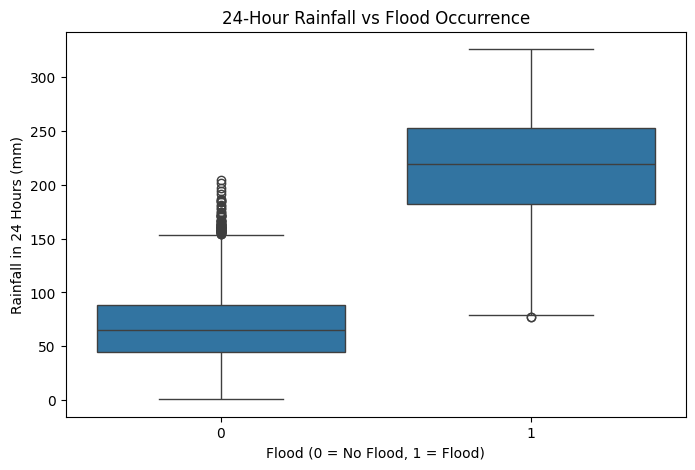

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="flood",
    y="rainfall_24h_mm"
)

plt.title("24-Hour Rainfall vs Flood Occurrence")
plt.xlabel("Flood (0 = No Flood, 1 = Flood)")
plt.ylabel("Rainfall in 24 Hours (mm)")

plt.show()

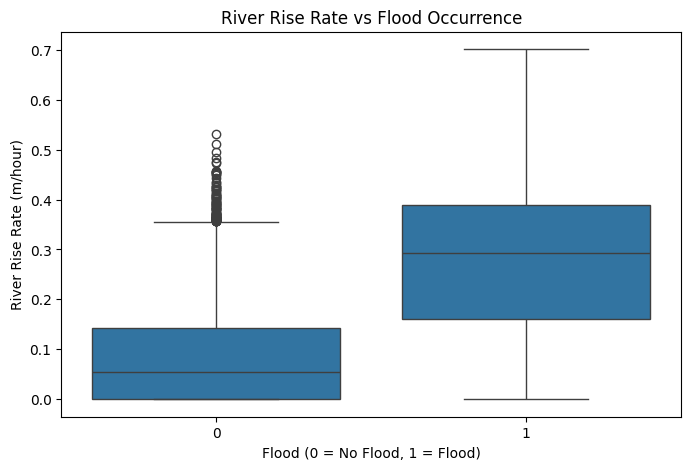

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="flood",
    y="river_rise_rate_m_per_hr"
)

plt.title("River Rise Rate vs Flood Occurrence")
plt.xlabel("Flood (0 = No Flood, 1 = Flood)")
plt.ylabel("River Rise Rate (m/hour)")

plt.show()

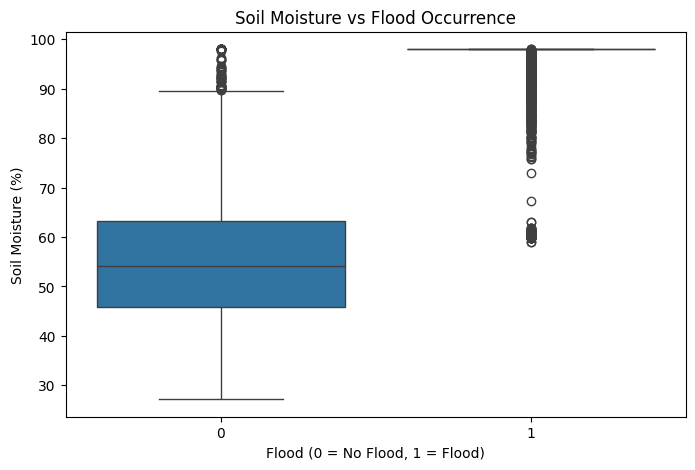

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="flood",
    y="soil_moisture_percent"
)

plt.title("Soil Moisture vs Flood Occurrence")
plt.xlabel("Flood (0 = No Flood, 1 = Flood)")
plt.ylabel("Soil Moisture (%)")

plt.show()

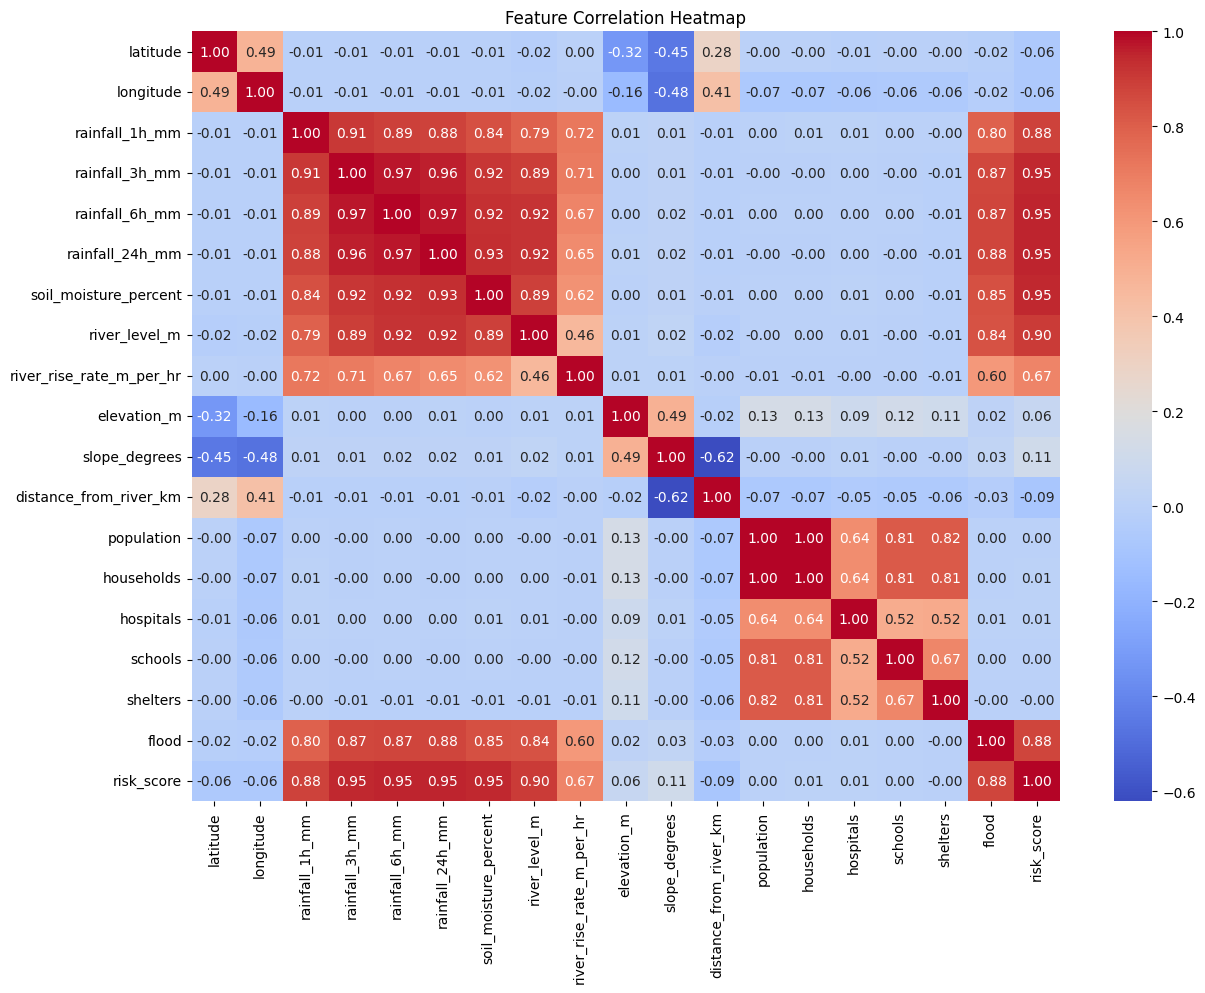

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [11]:
print(df["location"].value_counts())

location
Agasthyamalai           500
Anamalai Foothills      500
Biligiriranga Hills     500
Javadi Hills            500
Kalrayan Hills          500
Kodaikanal Hills        500
Kolli Hills             500
Kurinji Nagar           500
Meghamalai              500
Mullai Valley           500
Munnar Hills            500
Nilgiri Foothills       500
Pachamalai              500
Sathyamangalam Hills    500
Shevaroy Hills          500
Sirumalai               500
Thalamalai              500
Valparai                500
Yelagiri                500
Yercaud                 500
Name: count, dtype: int64


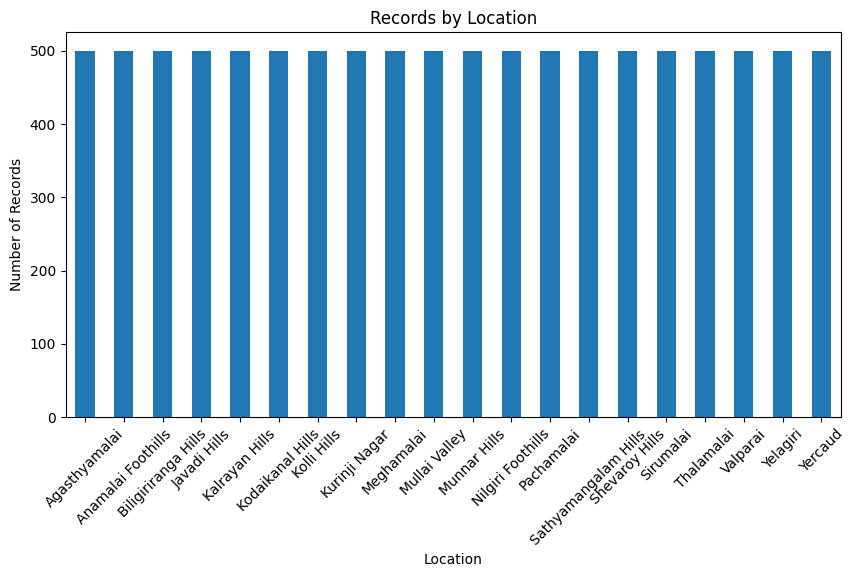

In [12]:
plt.figure(figsize=(10, 5))

df["location"].value_counts().plot(kind="bar")

plt.title("Records by Location")
plt.xlabel("Location")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

In [13]:
df.describe()

,latitude,longitude,rainfall_1h_mm,rainfall_3h_mm,rainfall_6h_mm,rainfall_24h_mm,soil_moisture_percent,river_level_m,river_rise_rate_m_per_hr,elevation_m,slope_degrees,distance_from_river_km,population,households,hospitals,schools,shelters,flood,risk_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.075996,77.633969,28.035720,43.649741,61.488099,108.606927,66.323574,3.333175,0.135487,1160.290090,30.495936,1.227250,4789.629400,1139.678500,1.371000,3.992900,2.662700,0.269000,45.582015
std,0.951959,0.711778,21.805389,30.553809,42.473260,74.441979,21.155454,1.239587,0.141844,323.652229,6.695708,0.621836,1458.802884,348.307252,0.637808,1.463784,0.986522,0.443462,18.249920
min,8.644755,76.745226,0.000000,0.000000,0.150000,0.890000,27.170000,1.010000,0.000000,587.100000,13.580000,0.100000,2484.000000,520.000000,0.000000,0.000000,1.000000,0.000000,9.160000
25%,10.305768,77.046129,12.597500,20.420000,29.370000,52.137500,48.757500,2.380000,0.000000,937.050000,25.340000,0.760000,3401.750000,809.000000,1.000000,3.000000,2.000000,0.000000,31.110000
50%,11.275831,77.350046,21.600000,33.210000,46.335000,81.685000,60.620000,2.820000,0.094000,1125.500000,30.475000,1.100000,4740.500000,1129.500000,1.000000,4.000000,3.000000,0.000000,40.075000
75%,11.708074,78.244819,40.380000,62.555000,88.255000,157.050000,89.937500,4.240000,0.222000,1350.100000,35.660000,1.610000,5943.250000,1415.000000,2.000000,5.000000,3.000000,1.000000,60.872500
max,12.585486,78.956991,420.000000,137.280000,187.940000,325.910000,98.000000,6.000000,0.701000,2105.300000,48.910000,3.160000,7721.000000,1886.000000,3.000000,9.000000,6.000000,1.000000,91.730000
